In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.3 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot_20260708_141342_Google.jpg to Screenshot_20260708_141342_Google.jpg


In [ ]:
results = model.predict(
      source=".",
          classes=[0],      # Detect only persons
              save=True,
                  conf=0.4
                  )



image 1/1 /content/Screenshot_20260708_141342_Google.jpg: 640x544 13 persons, 66.5ms
Speed: 10.8ms preprocess, 66.5ms inference, 89.7ms postprocess per image at shape (1, 3, 640, 544)
Results saved to /content/runs/detect/predict


In [ ]:
person_count = 13
if person_count <= 5:
 density = "Low Crowd Density"
elif person_count <= 15:
  density = "Medium Crowd Density"
else:
  density = "High Crowd Density"

print("Total Visitors Detected:", person_count)
print("Crowd Density:", density)

Total Visitors Detected: 13
Crowd Density: Medium Crowd Density


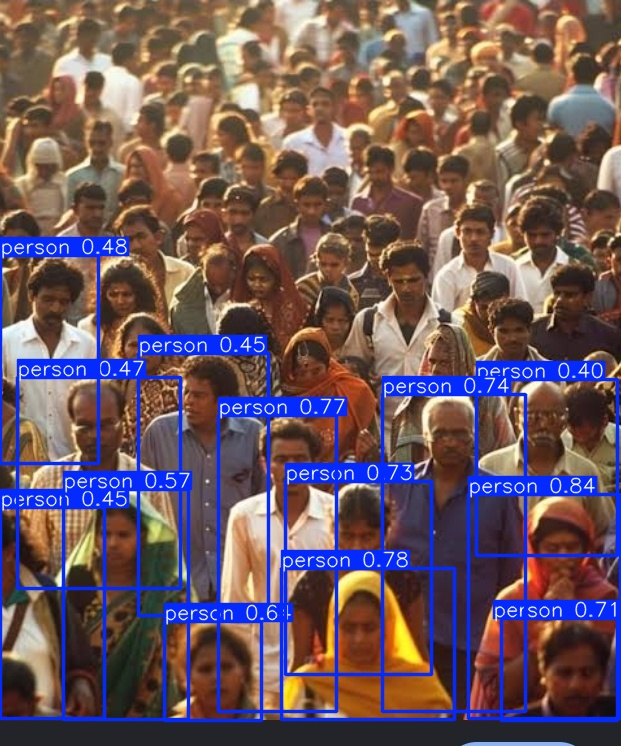

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/Screenshot_20260708_141342_Google.jpg"))

In [ ]:
from google.colab import files

files.download("/content/runs/detect/predict/Screenshot_20260708_141342_Google.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results = model.predict(
      source="/content/Screenshot_20260708_141342_Google.jpg",
          classes=[0],
              conf=0.4
              )

person_count = len(results[0].boxes)


print("Total Visitors:", person_count)



image 1/1 /content/Screenshot_20260708_141342_Google.jpg: 640x544 13 persons, 7.5ms
Speed: 2.7ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 544)
Total Visitors: 13


In [ ]:
if person_count <= 5:
      density = "Low Crowd Density"
elif person_count <= 15:
  density = "Medium Crowd Density"
else:
  density = "High Crowd Density"

print("Crowd Density:", density)

Crowd Density: Medium Crowd Density


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
image = results[0].orig_img
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
height, width = image.shape[:2]

heatmap = np.zeros((height, width), dtype=np.float32)

In [ ]:
heatmap = np.zeros((height, width), dtype=np.float32)

for box in results[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    center_x = int((x1 + x2) / 2)
    center_y = int((y1 + y2) / 2)

    cv2.circle(heatmap,(center_y, center_x), 80 ,1,-1)

    heatmap = cv2.GaussianBlur(heatmap, (201, 201), 0)

In [ ]:
heatmap = heatmap/heatmap.max()

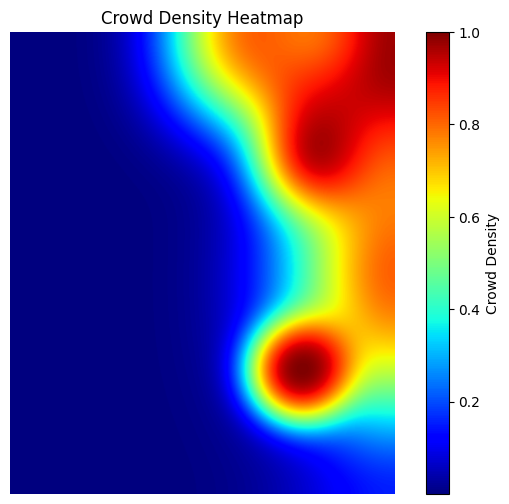

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar(label="Crowd Density")
plt.title("Crowd Density Heatmap")
plt.axis("off")
plt.show()

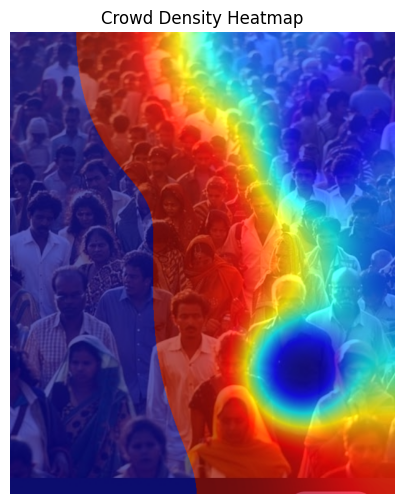

In [ ]:
heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap*255, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

overlay = cv2.addWeighted (image, 0.35, heatmap_color, 0.75, 0)
plt.figure(figsize=(8,6))
plt.imshow(overlay)
plt.title("Crowd Density Heatmap")
plt.axis("off")
plt.show()

In [ ]:
cv2.imwrite(
      "crowd_heatmap_overlay.jpg",
          cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
          )


True

In [ ]:
from google.colab import files

files.download("/content/crowd_heatmap_overlay.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>